# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2614s 15us/step


In [ ]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


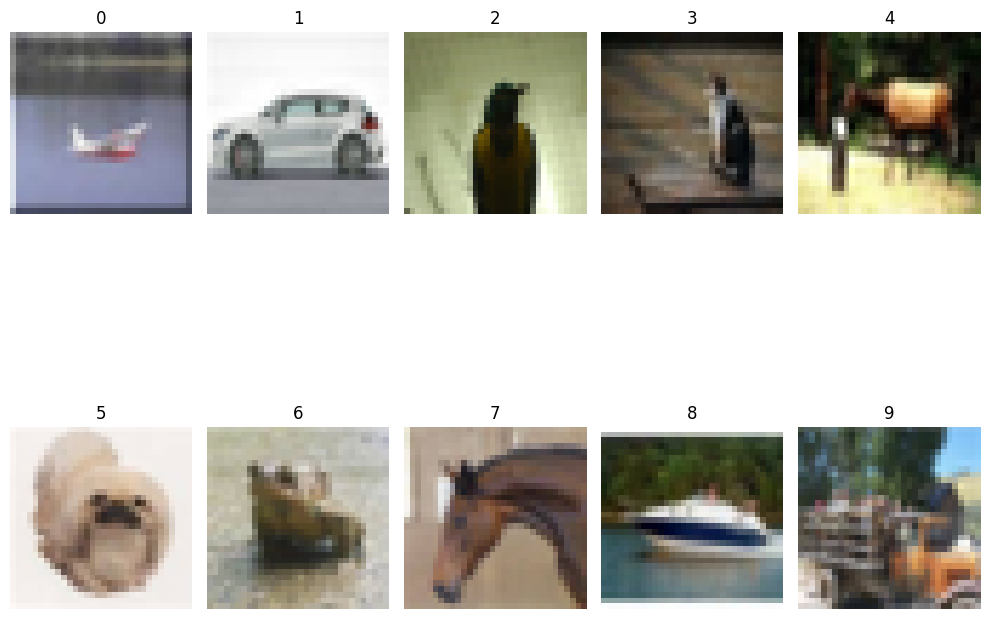

In [ ]:
# Visualize random samples from each class
np.random.seed(42)


fig, axes = plt.subplots(2, 5, figsize=(10, 10))
axes = axes.flatten()

for class_idx in range(10):
    class_indices = np.where(y_train == class_idx)[0]
    sample_idx = np.random.choice(class_indices)

    axes[class_idx].imshow(x_train[sample_idx])
    axes[class_idx].set_title(class_idx)
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Convert labels to one-hot encoded form
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


In [ ]:
# Normalize the images
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
# Your code here :
model = Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [ ]:
# Compile the model
model.compile(optimizer= 'sgd', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, batch_size=512, epochs=50, validation_split=0.1)

print(history.history.keys())

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.1714 - loss: 2.2492 - val_accuracy: 0.2098 - val_loss: 2.1936
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2405 - loss: 2.1397 - val_accuracy: 0.2686 - val_loss: 2.0885
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2842 - loss: 2.0389 - val_accuracy: 0.2878 - val_loss: 2.0009
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3110 - loss: 1.9653 - val_accuracy: 0.3164 - val_loss: 1.9427
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3289 - loss: 1.9164 - val_accuracy: 0.3364 - val_loss: 1.9071
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3447 - loss: 1.8807 - val_accuracy: 0.3468 - val_loss: 1.8733
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3552 - loss: 1.8532 - val_accuracy: 0.3558 - val_loss: 1.8596
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3662 - loss: 1.8256 - val_accuracy: 0.3658 - v

*   Plot the cross entropy loss curve and the accuracy curve

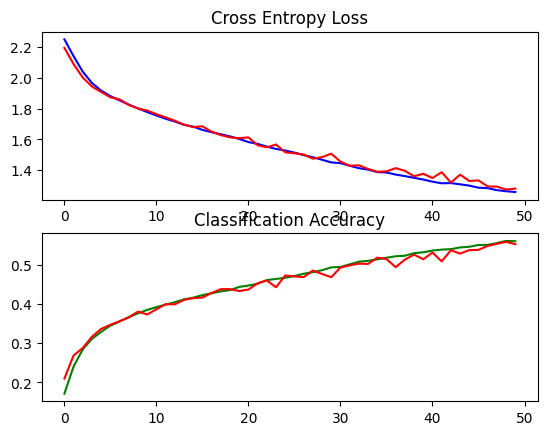

In [ ]:
# Plot loss curve and accuracy curve
model1_loss = history.history['loss']
model1_acc = history.history['accuracy']

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(model1_loss, color='blue', label='train')
plt.plot(history.history['val_loss'], color='red', label='val')

# plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(model1_acc, color='green', label='train')
plt.plot(history.history['val_accuracy'], color='red', label='val')
plt.show()

In [ ]:
# Print loss and accuracy of test

test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5431 - loss: 1.2809
Test loss: 1.2809300422668457
Test accuracy: 0.5430999994277954


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
# Your code here :
model2 = Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       819,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,454 (3.17 MB)

 Trainable params: 830,454 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [ ]:
# Compile the model
model2.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
history = model2.fit(x_train, y_train, batch_size=512, epochs=50, validation_split=0.1)

print(history.history.keys())

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.1576 - loss: 2.2587 - val_accuracy: 0.1866 - val_loss: 2.2128
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2278 - loss: 2.1599 - val_accuracy: 0.2284 - val_loss: 2.1289
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2699 - loss: 2.0691 - val_accuracy: 0.2764 - val_loss: 2.0407
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2983 - loss: 1.9979 - val_accuracy: 0.3206 - val_loss: 1.9446
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3218 - loss: 1.9407 - val_accuracy: 0.3246 - val_loss: 1.9210
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3421 - loss: 1.8864 - val_accuracy: 0.3278 - val_loss: 1.8936
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3627 - loss: 1.8356 - val_accuracy: 0.3498 - val_loss: 1.8370
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3725 - loss: 1.7983 - val_accuracy: 0.3662 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


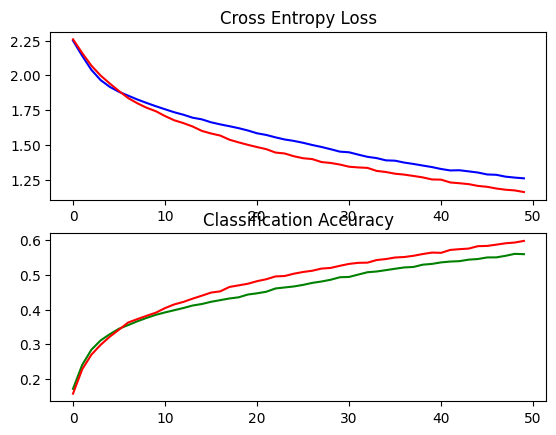

In [ ]:
# Your code here :
model2_loss = history.history['loss']
model2_acc = history.history['accuracy']

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(model1_loss, color='blue', label='train')
plt.plot(model2_loss, color='red', label='val')

# plot accuracy
plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(model1_acc, color='green', label='train')
plt.plot(model2_acc, color='red', label='val')
plt.show()

**Comment on the observation**

*The second model is performing slightly better than the first one, with 0.59 accuracy compared to 0.55 in the first model, but can further be improved.*

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [ ]:
from sklearn.metrics import confusion_matrix

# Predict the output for the test split
y_pred = model2.predict(x_test)

# Plot confusion matrix
predictions = np.argmax(y_pred, axis=1)
y_true  = np.argmax(y_test, axis=1)

confusion_matrix(y_true, predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[571,  61,  37,  30,  34,   6,  37,  26, 144,  54],
       [ 21, 753,   3,  14,   4,   3,  24,  18,  34, 126],
       [ 61,  19, 330,  85, 163,  52, 162,  78,  28,  22],
       [ 17,  25,  31, 435,  91,  89, 191,  69,  17,  35],
       [ 33,  10,  49,  68, 515,  22, 179,  91,  17,  16],
       [  9,   7,  43, 252, 102, 336, 109, 104,  16,  22],
       [  2,  16,  30,  53,  72,  11, 770,  23,  11,  12],
       [ 14,  16,  17,  68,  65,  40,  62, 676,   8,  34],
       [ 73,  94,  11,  27,  14,   4,  15,  14, 682,  66],
       [ 25, 197,   7,  25,   6,  10,  34,  42,  33, 621]])

**Comment here :**

IT's clear that numbers on the diagonal of the matrix are bigger than other numbers, which means the performance is good. However, further improvements need to be done.

*    Print the test accuracy for the trained model.

In [ ]:
# Your code here :

test_loss, test_acc = model2.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5689 - loss: 1.2246
Test loss: 1.2246437072753906
Test accuracy: 0.5688999891281128


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
# Resize images from 32x32 to 64x64
x_train_resized = tf.image.resize(x_train, (64, 64)).numpy()
x_test_resized = tf.image.resize(x_test, (64, 64)).numpy()

print(x_train_resized.shape)


# Build the model
model3 = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 3)),

    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model3.summary()

(50000, 64, 64, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [ ]:
# Compile the model
model3.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history3 = model3.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 124s 919ms/step - accuracy: 0.1178 - loss: 2.3010 - val_accuracy: 0.1260 - val_loss: 2.2980
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 455ms/step - accuracy: 0.1334 - loss: 2.2951 - val_accuracy: 0.1369 - val_loss: 2.2902
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 454ms/step - accuracy: 0.1546 - loss: 2.2821 - val_accuracy: 0.1789 - val_loss: 2.2673
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 456ms/step - accuracy: 0.2064 - loss: 2.2255 - val_accuracy: 0.2157 - val_loss: 2.1486
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 456ms/step - accuracy: 0.2324 - loss: 2.1309 - val_accuracy: 0.2282 - val_loss: 2.1353
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 456ms/step - accuracy: 0.2767 - loss: 2.0487 - val_accuracy: 0.2942 - val_loss: 1.9873
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 455ms/step - accuracy: 0.3029 - loss: 1.9774 - val_accuracy: 0.3134 - val_loss: 1.9207
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 456ms/step - accuracy: 0.3264 - loss: 1.9057 - val_acc

In [ ]:
# Predict the output for the test split
y_pred = model3.predict(x_test_resized)

# Plot confusion matrix
predictions = np.argmax(y_pred, axis=1)
y_true  = np.argmax(y_test, axis=1)

confusion_matrix(y_true, predictions)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


array([[616, 106,   0,   1,   5,  12,  12, 140,  68,  40],
       [ 75, 612,   1,   3,  10,  23,  17, 135,  25,  99],
       [188, 104,  44,  11,  29,  82,  46, 461,  14,  21],
       [ 95, 139,  12,  39,  14, 228,  56, 346,  11,  60],
       [ 85,  66,  48,  10,  82,  67,  68, 553,   8,  13],
       [ 89, 110,  13,  19,   6, 288,  50, 372,  25,  28],
       [ 28,  86,  35,  12,  74,  97, 242, 380,   4,  42],
       [ 68,  68,   0,   6,   5,  45,  16, 735,   7,  50],
       [299, 171,   0,   5,   0,  26,   5, 101, 314,  79],
       [ 87, 293,   2,   6,   0,  16,  17, 176,  32, 371]])

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
-  An activation function is a small mathematical function applied to the output of a neuron, which decides what value that neuron passes on to the next layer. Activation functions are needed to provide non-linearity to models. Without them, a deep network collapses into a single linear function.

2 - Key Differences between sigmoid and softmax:

- Sigmoid scores each output independently | Used for binary outputs (ex: spam vs non-spam)
- Softmax scores all outputs together so they compete and sum to 1 | Used for multi-class classification (ex: digit 0-9)

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

- Binary crossentropy measures error for yes/no predictions | Used for sigmoid functions.
- Categorical crossentropy measures error when exactly one of several classes is correct | Used for softmax functions.